In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
import os
import xml.etree.ElementTree as ET
import json
import shutil
import random
import cv2
from sklearn.model_selection import train_test_split

BASE_PATH = r"C:\Users\vishn\Downloads\WBC"
WORK_DIR = r"C:\Users\vishn\Downloads\WBC\outputs"

IMG_OUT = f"{WORK_DIR}/images"
DATASET_DIR = f"{WORK_DIR}/dataset"

os.makedirs(IMG_OUT, exist_ok=True)

In [4]:
from collections import Counter

size_counts = Counter()

for img_name in os.listdir(IMG_OUT):
    path = os.path.join(IMG_OUT, img_name)
    
    image = cv2.imread(path)
    if image is None:
        continue
    
    h, w = image.shape[:2]
    size_counts[(w, h)] += 1

# Print results
for size, count in size_counts.items():
    print(f"{size} → {count} images")

In [5]:
valid_folders = []

for folder in os.listdir(BASE_PATH):
    folder_path = os.path.join(BASE_PATH, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    # must contain annotations.xml
    if "annotations.xml" in os.listdir(folder_path):
        valid_folders.append(folder)

print("✅ Valid folders:", valid_folders)

✅ Valid folders: ['BAND CELLS', 'BASOPHILS', 'BLAST CELLS', 'EOSINOPHILS', 'LYMPHOCYTES', 'METAMYELOCYTES', 'MONOCYTES', 'MYELOCYTE', 'NEUTROPHILS', 'PROMYELOCYTES']


In [6]:
images = []
annotations = []
categories = {}

ann_id = 1
img_id = 1
cat_id = 1

for folder in valid_folders:
    folder_path = os.path.join(BASE_PATH, folder)
    xml_path = os.path.join(folder_path, "annotations.xml")
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # categories
    for label in root.findall(".//label"):
        name = label.find("name").text.strip()
        
        if name == "bg":
            continue
        
        if name not in categories:
            categories[name] = cat_id
            cat_id += 1
    
    # images
    for image in root.findall("image"):
        file_name = image.get("name")
        width = int(image.get("width"))
        height = int(image.get("height"))
        
        src = os.path.join(folder_path, file_name)
        new_name = f"{folder}_{file_name}"
        dst = os.path.join(IMG_OUT, new_name)
        
        if not os.path.exists(dst):
            shutil.copy(src, dst)
        
        images.append({
            "id": img_id,
            "file_name": new_name,
            "width": width,
            "height": height
        })
        
        for poly in image.findall("polygon"):
            label = poly.get("label").strip()
            if label == "bg":
                continue
            
            coords = []
            for p in poly.get("points").split(";"):
                x, y = map(float, p.split(","))
                coords.extend([x, y])
            
            xs = coords[0::2]
            ys = coords[1::2]
            
            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)
            
            annotations.append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": categories[label],
                "segmentation": [coords],
                "bbox": [xmin, ymin, xmax-xmin, ymax-ymin],
                "area": (xmax-xmin)*(ymax-ymin),
                "iscrowd": 0
            })
            
            ann_id += 1
        
        img_id += 1

coco = {
    "images": images,
    "annotations": annotations,
    "categories": [{"id": v, "name": k} for k, v in categories.items()]
}

with open(f"{WORK_DIR}/full_annotations.json", "w") as f:
    json.dump(coco, f)

print("✅ COCO conversion done!")

✅ COCO conversion done!


In [7]:
import json
from collections import defaultdict

# load annotations
with open(f"{WORK_DIR}/full_annotations.json") as f:
    coco = json.load(f)

# map category_id → name
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

# map class → set of image_ids (to avoid duplicates)
class_to_images = defaultdict(set)

for ann in coco["annotations"]:
    class_id = ann["category_id"]
    img_id = ann["image_id"]
    
    class_to_images[class_id].add(img_id)

# print results
print("📊 Image count per class:\n")

for class_id, img_ids in class_to_images.items():
    print(f"{cat_id_to_name[class_id]} → {len(img_ids)} images")

📊 Image count per class:

band cell → 60 images
basophil → 26 images
blast cell → 68 images
eosinophil → 67 images
lymphocyte → 60 images
metamyelocyte → 31 images
monocyte → 53 images
myelocyte → 83 images
neutrophil → 99 images
promyelocyte → 36 images


In [8]:
RESIZE = 256

# load coco
with open(f"{WORK_DIR}/full_annotations.json") as f:
    coco = json.load(f)

for img in coco["images"]:
    img_path = os.path.join(IMG_OUT, img["file_name"])
    
    image = cv2.imread(img_path)
    if image is None:
        continue
    
    orig_h, orig_w = image.shape[:2]

    # compute scaling factors (per image!)
    scale_x = RESIZE / orig_w
    scale_y = RESIZE / orig_h

    # resize image
    resized = cv2.resize(image, (RESIZE, RESIZE))
    cv2.imwrite(img_path, resized)

    # update image metadata
    img["width"] = RESIZE
    img["height"] = RESIZE

    # update annotations for this image
    for ann in coco["annotations"]:
        if ann["image_id"] == img["id"]:

            # 🔹 scale bbox
            x, y, w, h = ann["bbox"]
            ann["bbox"] = [
                x * scale_x,
                y * scale_y,
                w * scale_x,
                h * scale_y
            ]

            # 🔹 scale segmentation
            new_seg = []
            for seg in ann["segmentation"]:
                scaled = []
                for i in range(0, len(seg), 2):
                    scaled.append(seg[i] * scale_x)     # x
                    scaled.append(seg[i+1] * scale_y)   # y
                new_seg.append(scaled)
            
            ann["segmentation"] = new_seg

# save updated annotations
with open(f"{WORK_DIR}/full_annotations.json", "w") as f:
    json.dump(coco, f, indent=4)

print("✅ Images + annotations resized correctly!")

✅ Images + annotations resized correctly!


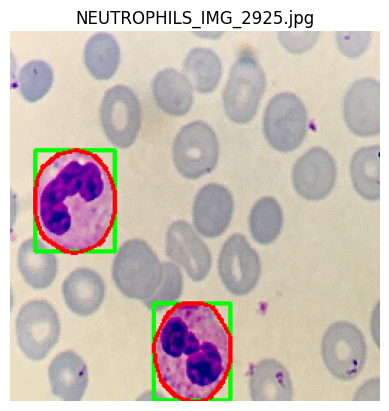

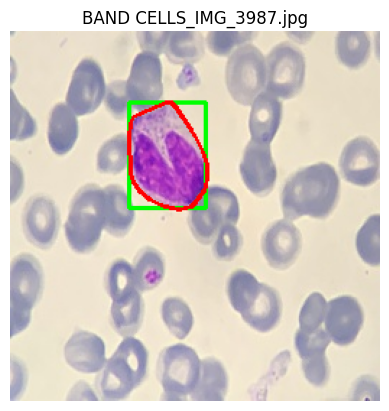

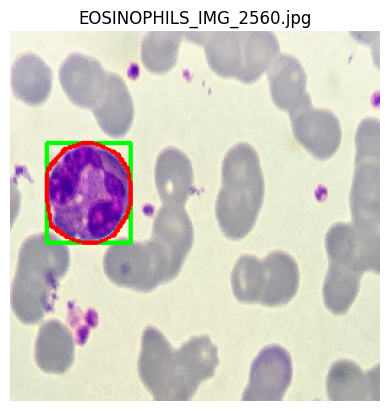

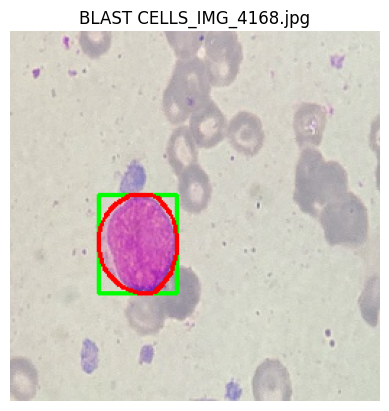

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# load annotations
with open(f"{WORK_DIR}/full_annotations.json") as f:
    coco = json.load(f)

# map image_id → annotations
img_to_anns = {}
for ann in coco["annotations"]:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

# pick 4 random images
sample_images = random.sample(coco["images"], 4)

for img in sample_images:
    img_path = os.path.join(IMG_OUT, img["file_name"])
    image = cv2.imread(img_path)

    if image is None:
        print("❌ Error loading:", img_path)
        continue

    # draw annotations
    anns = img_to_anns.get(img["id"], [])

    for ann in anns:
        # 🔹 draw bbox
        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # 🔹 draw segmentation
        for seg in ann["segmentation"]:
            pts = [(int(seg[i]), int(seg[i+1])) for i in range(0, len(seg), 2)]
            pts = cv2.convexHull(np.array(pts))
            cv2.polylines(image, [pts], isClosed=True, color=(0, 0, 255), thickness=2)

    # show image
    plt.figure()
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(img["file_name"])
    plt.axis("off")
    plt.show()

In [10]:
import os
import json
import shutil
from sklearn.model_selection import train_test_split

# paths
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train/images")
VAL_IMG_DIR = os.path.join(DATASET_DIR, "valid/images")

os.makedirs(TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(VAL_IMG_DIR, exist_ok=True)

# load coco
with open(f"{WORK_DIR}/full_annotations.json") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# -----------------------------------
# STEP 1: image_id → annotations map
# -----------------------------------
img_to_anns = {}
for ann in annotations:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

# -----------------------------------
# STEP 2: prepare stratification labels
# (use first category of each image)
# -----------------------------------
image_labels = []

for img in images:
    anns = img_to_anns.get(img["id"], [])
    
    if len(anns) == 0:
        image_labels.append(-1)  # no object
    else:
        image_labels.append(anns[0]["category_id"])

# -----------------------------------
# STEP 3: train/val split
# -----------------------------------
train_imgs, val_imgs = train_test_split(
    images,
    test_size=0.2,
    random_state=42,
    stratify=image_labels
)

# -----------------------------------
# STEP 4: collect image IDs
# -----------------------------------
train_ids = set(img["id"] for img in train_imgs)
val_ids = set(img["id"] for img in val_imgs)

# -----------------------------------
# STEP 5: split annotations
# -----------------------------------
train_anns = [ann for ann in annotations if ann["image_id"] in train_ids]
val_anns = [ann for ann in annotations if ann["image_id"] in val_ids]

# -----------------------------------
# STEP 6: copy images
# -----------------------------------
def copy_images(img_list, dest_folder):
    for img in img_list:
        src = os.path.join(IMG_OUT, img["file_name"])
        dst = os.path.join(dest_folder, img["file_name"])
        
        if not os.path.exists(dst):
            shutil.copy(src, dst)

copy_images(train_imgs, TRAIN_IMG_DIR)
copy_images(val_imgs, VAL_IMG_DIR)

# -----------------------------------
# STEP 7: save COCO files
# -----------------------------------
train_coco = {
    "images": train_imgs,
    "annotations": train_anns,
    "categories": categories
}

val_coco = {
    "images": val_imgs,
    "annotations": val_anns,
    "categories": categories
}

with open(os.path.join(DATASET_DIR, "train/annotations.json"), "w") as f:
    json.dump(train_coco, f, indent=4)

with open(os.path.join(DATASET_DIR, "valid/annotations.json"), "w") as f:
    json.dump(val_coco, f, indent=4)

print("✅ Train/Val split completed!")
print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")

✅ Train/Val split completed!
Train images: 466
Val images: 117


In [11]:
os.makedirs(f"{DATASET_DIR}/train/images", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/valid/images", exist_ok=True)

# copy images
id_to_name = {img["id"]: img["file_name"] for img in coco["images"]}

for i in train_ids:
    shutil.copy(f"{IMG_OUT}/{id_to_name[i]}", f"{DATASET_DIR}/train/images")

for i in val_ids:
    shutil.copy(f"{IMG_OUT}/{id_to_name[i]}", f"{DATASET_DIR}/valid/images")

# save annotations
with open(f"{DATASET_DIR}/train/annotations.json", "w") as f:
    json.dump(train_coco, f)

with open(f"{DATASET_DIR}/valid/annotations.json", "w") as f:
    json.dump(val_coco, f)

print("✅ Dataset ready!")

✅ Dataset ready!


In [12]:
import os

os.rename(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\train\annotations.json",
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\train\_annotations.coco.json"
)

os.rename(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\annotations.json",
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json"
)

print("✅ Fixed annotation filenames!")

✅ Fixed annotation filenames!


In [13]:
import json

def fix_paths(json_path):
    with open(json_path) as f:
        data = json.load(f)

    for img in data["images"]:
        img["file_name"] = "images/" + img["file_name"]

    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

# Fix both
fix_paths(r"C:\Users\vishn\Downloads\WBC\outputs\dataset\train\_annotations.coco.json")
fix_paths(r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json")

print("✅ Fixed image paths in JSON!")

✅ Fixed image paths in JSON!


In [14]:
from collections import defaultdict

def get_class_distribution(json_path):
    with open(json_path) as f:
        coco = json.load(f)

    # map category_id → name
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

    # class → unique image_ids
    class_to_images = defaultdict(set)

    for ann in coco["annotations"]:
        class_to_images[ann["category_id"]].add(ann["image_id"])

    # convert to readable dict
    result = {}
    for class_id, img_ids in class_to_images.items():
        result[cat_id_to_name[class_id]] = len(img_ids)

    return result


# paths
train_json = f"{DATASET_DIR}/train/_annotations.coco.json"
val_json = f"{DATASET_DIR}/valid/_annotations.coco.json"

train_dist = get_class_distribution(train_json)
val_dist = get_class_distribution(val_json)

# merge and print
all_classes = sorted(set(train_dist.keys()) | set(val_dist.keys()))

print("📊 Train vs Validation Distribution:\n")

for cls in all_classes:
    train_count = train_dist.get(cls, 0)
    val_count = val_dist.get(cls, 0)
    print(f"{cls:15} → Train: {train_count:3} | Val: {val_count:3}")

📊 Train vs Validation Distribution:

band cell       → Train:  48 | Val:  12
basophil        → Train:  21 | Val:   5
blast cell      → Train:  54 | Val:  14
eosinophil      → Train:  54 | Val:  13
lymphocyte      → Train:  48 | Val:  12
metamyelocyte   → Train:  25 | Val:   6
monocyte        → Train:  42 | Val:  11
myelocyte       → Train:  66 | Val:  17
neutrophil      → Train:  79 | Val:  20
promyelocyte    → Train:  29 | Val:   7


In [15]:
import os
import cv2
import json
import random
import numpy as np
import albumentations as A

# -----------------------------
# CONFIG
# -----------------------------
DATASET_DIR = f"{WORK_DIR}/dataset"
IMG_DIR = f"{DATASET_DIR}/train/images"
ANN_PATH = f"{DATASET_DIR}/train/_annotations.coco.json"

TARGET = 80

# -----------------------------
# AUGMENTATION PIPELINE
# -----------------------------
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.2),
    A.RandomGamma(p=0.3),
])

# -----------------------------
# LOAD COCO
# -----------------------------
with open(ANN_PATH) as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

# -----------------------------
# BUILD MAPPINGS
# -----------------------------
img_to_anns = {}
for ann in annotations:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

class_to_images = {}
for ann in annotations:
    class_to_images.setdefault(ann["category_id"], set()).add(ann["image_id"])

# -----------------------------
# ID START
# -----------------------------
new_img_id = max(img["id"] for img in images) + 1
new_ann_id = max(ann["id"] for ann in annotations) + 1

new_images = []
new_annotations = []

# -----------------------------
# FUNCTION: POLYGON → MASK
# -----------------------------
def polygons_to_mask(polygons, height, width, value):
    mask = np.zeros((height, width), dtype=np.uint16)
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], value)
    return mask

# -----------------------------
# AUGMENTATION LOOP
# -----------------------------
for class_id, img_ids in class_to_images.items():
    img_ids = list(img_ids)
    current = len(img_ids)

    if current >= TARGET:
        continue

    needed = TARGET - current
    print(f"🔄 Class {class_id}: {current} → {TARGET}")

    for _ in range(needed):
        chosen_img_id = random.choice(img_ids)
        img_info = next(img for img in images if img["id"] == chosen_img_id)

        file_name = img_info["file_name"].replace("images/", "")
        img_path = os.path.join(IMG_DIR, file_name)

        image = cv2.imread(img_path)
        if image is None:
            continue

        h, w = image.shape[:2]
        anns = img_to_anns.get(chosen_img_id, [])
        if len(anns) == 0:
            continue

        # -----------------------------
        # BUILD INSTANCE MASK (SAFE)
        # -----------------------------
        instance_mask = np.zeros((h, w), dtype=np.uint16)
        id_to_cat = {}

        for idx, ann in enumerate(anns, start=1):
            temp = polygons_to_mask(ann["segmentation"], h, w, idx)

            mask_region = temp > 0

            # only fill empty pixels (avoid overwrite)
            instance_mask[mask_region] = np.where(
                instance_mask[mask_region] == 0,
                idx,
                instance_mask[mask_region]
            )

            id_to_cat[idx] = ann["category_id"]

        # -----------------------------
        # APPLY AUGMENTATION
        # -----------------------------
        transformed = transform(image=image, mask=instance_mask)

        aug_img = transformed["image"]
        aug_mask = transformed["mask"]

        # -----------------------------
        # SAVE IMAGE
        # -----------------------------
        new_name = f"aug_{new_img_id}.jpg"
        cv2.imwrite(os.path.join(IMG_DIR, new_name), aug_img)

        new_images.append({
            "id": new_img_id,
            "file_name": "images/" + new_name,
            "width": aug_img.shape[1],
            "height": aug_img.shape[0],
        })

        # -----------------------------
        # EXTRACT INSTANCES
        # -----------------------------
        unique_ids = np.unique(aug_mask)

        for obj_id in unique_ids:
            if obj_id == 0:
                continue

            mask = (aug_mask == obj_id).astype(np.uint8)

            # compute area once
            area = int(mask.sum())
            if area < 10:
                continue

            contours, _ = cv2.findContours(
                mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            polygons = []
            for cnt in contours:

                if cv2.contourArea(cnt) < 10:
                    continue

                if len(cnt) >= 3:
                    epsilon = 0.01 * cv2.arcLength(cnt, True)
                    cnt = cv2.approxPolyDP(cnt, epsilon, True)

                    poly = cnt.flatten().tolist()
                    if len(poly) >= 6:
                        polygons.append(poly)

            if len(polygons) == 0:
                continue

            ys, xs = np.where(mask > 0)
            xmin, xmax = xs.min(), xs.max()
            ymin, ymax = ys.min(), ys.max()

            bbox = [
                float(xmin),
                float(ymin),
                float(xmax - xmin),
                float(ymax - ymin),
            ]

            new_annotations.append({
                "id": new_ann_id,
                "image_id": new_img_id,
                "category_id": id_to_cat[obj_id],
                "bbox": bbox,
                "segmentation": polygons,
                "area": float(area),
                "iscrowd": 0
            })
            new_ann_id += 1

        new_img_id += 1

# -----------------------------
# SAVE COCO
# -----------------------------
coco["images"].extend(new_images)
coco["annotations"].extend(new_annotations)

with open(ANN_PATH, "w") as f:
    json.dump(coco, f, indent=4)

print("✅ FINAL PRODUCTION augmentation complete!")

c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔄 Class 1: 48 → 80
🔄 Class 2: 21 → 80
🔄 Class 3: 54 → 80
🔄 Class 4: 54 → 80
🔄 Class 5: 48 → 80
🔄 Class 10: 25 → 80
🔄 Class 6: 42 → 80
🔄 Class 9: 66 → 80
🔄 Class 7: 79 → 80
🔄 Class 8: 29 → 80
✅ FINAL PRODUCTION augmentation complete!


In [16]:
from collections import defaultdict

def get_class_distribution(json_path):
    with open(json_path) as f:
        coco = json.load(f)

    # map category_id → name
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

    # class → unique image_ids
    class_to_images = defaultdict(set)

    for ann in coco["annotations"]:
        class_to_images[ann["category_id"]].add(ann["image_id"])

    # convert to readable dict
    result = {}
    for class_id, img_ids in class_to_images.items():
        result[cat_id_to_name[class_id]] = len(img_ids)

    return result


# paths
train_json = f"{DATASET_DIR}/train/_annotations.coco.json"
val_json = f"{DATASET_DIR}/valid/_annotations.coco.json"

train_dist = get_class_distribution(train_json)
val_dist = get_class_distribution(val_json)

# merge and print
all_classes = sorted(set(train_dist.keys()) | set(val_dist.keys()))

print("📊 Train vs Validation Distribution:\n")

for cls in all_classes:
    train_count = train_dist.get(cls, 0)
    val_count = val_dist.get(cls, 0)
    print(f"{cls:15} → Train: {train_count:3} | Val: {val_count:3}")

📊 Train vs Validation Distribution:

band cell       → Train:  80 | Val:  12
basophil        → Train:  80 | Val:   5
blast cell      → Train:  80 | Val:  14
eosinophil      → Train:  80 | Val:  13
lymphocyte      → Train:  80 | Val:  12
metamyelocyte   → Train:  80 | Val:   6
monocyte        → Train:  80 | Val:  11
myelocyte       → Train:  80 | Val:  17
neutrophil      → Train:  80 | Val:  20
promyelocyte    → Train:  80 | Val:   7


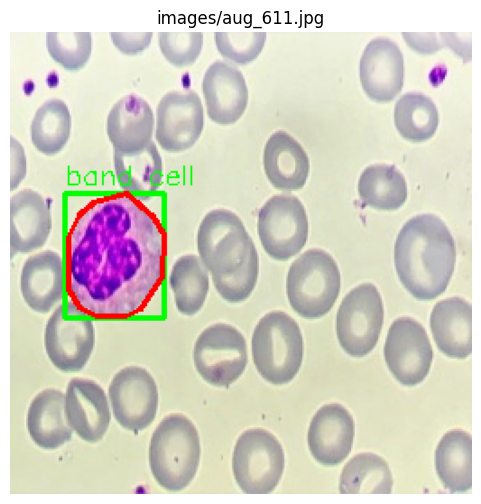

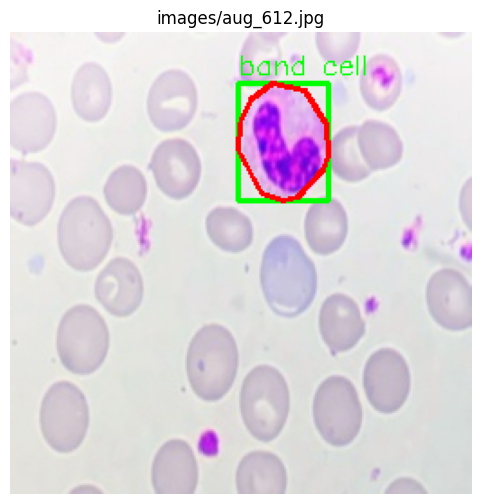

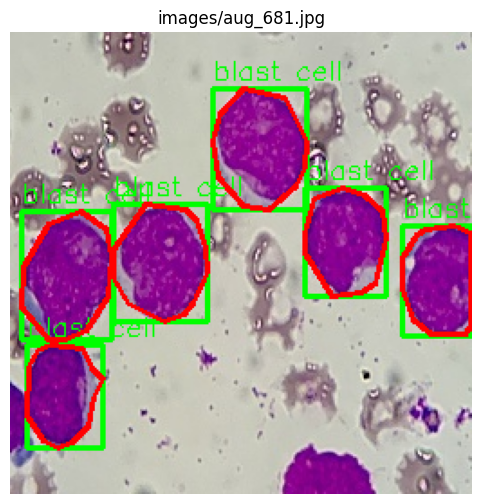

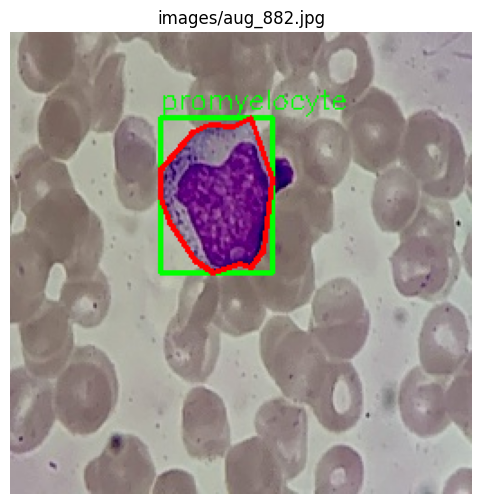

In [17]:
ANN_PATH = f"{DATASET_DIR}/train/_annotations.coco.json"
IMG_DIR = f"{DATASET_DIR}/train/images"

with open(ANN_PATH) as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# map image_id → annotations
img_to_anns = {}
for ann in annotations:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

# category id → name
cat_id_to_name = {cat["id"]: cat["name"] for cat in categories}

aug_images = [img for img in images if img["file_name"].startswith("images/aug_")]

sample_images = random.sample(aug_images, min(4, len(aug_images)))

for img in sample_images:
    file_name = img["file_name"].replace("images/", "")
    img_path = os.path.join(IMG_DIR, file_name)

    image = cv2.imread(img_path)
    if image is None:
        print("❌ Error loading:", img_path)
        continue

    anns = img_to_anns.get(img["id"], [])

    for ann in anns:
        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # label
        label = cat_id_to_name[ann["category_id"]]
        cv2.putText(image, label, (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        for seg in ann["segmentation"]:
            pts = [(int(seg[i]), int(seg[i+1])) for i in range(0, len(seg), 2)]
            pts = np.array(pts, dtype=np.int32)

            if len(pts) >= 3:
                cv2.polylines(image, [pts], isClosed=True, color=(0,0,255), thickness=2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(img["file_name"])
    plt.axis("off")
    plt.show()

In [18]:
from rfdetr import RFDETRSegPreview

model = RFDETRSegPreview()

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

model.train(
    dataset_dir=DATASET_DIR,
    epochs=15,
    batch_size=1,
    grad_accum_steps=8,
    lr=1e-4,
    precision=16,
    output_dir=f"{WORK_DIR}/output",
    early_stopping=False,
    save_weights_only=True
)

[2026-06-22 21:54:35] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-preview.pt


rf-detr-seg-preview.pt: 100%|██████████| 130M/130M [00:44<00:00, 3.06MiB/s] 


[2026-06-22 21:55:21] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-preview.pt


[2026-06-22 21:55:21] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-22 21:55:21] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-22 21:55:22] [INFO] rf-detr - File rf-detr-seg-preview.pt already exists with correct MD5 hash.


...

[2026-06-23 00:29:34] [INFO] rf-detr - Best EMA mAP improved to 0.8924 (epoch 13)


Val — Overall Metrics                               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃     segm mAP    ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │ 50:95  │   50   │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.8579 │ 0.9027 │ 0.9027 │ 0.9743 │ 0.8200 │ 0.8051 │ 0.8674 │ 0.8125 │ 0.9027 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘

                      Val — Per-class Metrics                      
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class         ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ band cell     │   0.8285 │ 0.9917 │ 0.7500 │    0.6000 │ 1.0000 │
│ basophil      │   0.8995 │ 0.9200 │ 1.0000 │    1.0000 │ 1.0000 │
│ blast cell    │   0.9496 │ 0.9800 │ 0.9310 │    0.9643 │ 0.9000 │
│ eosinophil    │   0.9644 │ 0.9824 │ 0.9714 │    0.9444 │ 1.0000 │
│ lymphocyte    │   0.9079 │ 0.9667 │ 0.8889 │    0.8000 │ 1.0000 │
│ monocyte      │   0.8645 │ 0.9909 │ 0.7826 │    0.7500 │ 0.8182 │
│ neutrophil    │   0.9331 │ 0.9727 │ 0.9565 │    0.9167 │ 1.0000 │
│ promyelocyte  │   0.8797 │ 0.9545 │ 0.8800 │    0.7857 │ 1.0000 │
│ myelocyte     │   0.7507 │ 0.9842 │ 0.7895 │    0.7895 │ 0.7895 │
│ metamyelocyte │   0.6008 │ 1.0000 │ 0.2500 │    0.5000 │ 0.1667 │
└───────────────┴──────────┴────────┴────────┴───────────┴────────┘

`Trainer.fit` stopped: `max_epochs=15` reached.


[2026-06-23 00:42:20] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.8817, ema=0.8924)
